In [1]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import v2


def upscale_image(model, model_path, image_path, output_path, device):
    checkpoint = torch.load(model_path, map_location=device)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)

    model.to(device)
    model.eval()

    image = Image.open(image_path).convert("RGB")

    to_tensor = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
    ])

    lr = to_tensor(image).unsqueeze(0).to(device)

    with torch.inference_mode():
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            sr = model(lr)

    sr = sr.float().clamp(0, 1)

    # Convert SR tensor to NumPy for matplotlib
    sr_np = sr.squeeze(0).cpu().permute(1, 2, 0).numpy()
    lr_np = lr.squeeze(0).cpu().permute(1, 2, 0).numpy()

    # Save SR image
    sr_uint8 = (sr_np * 255).round().astype("uint8")
    Image.fromarray(sr_uint8).save(output_path)

    # Display
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(lr_np)
    axes[0].set_title(f"LR Input ({image.width}×{image.height})")
    axes[0].axis("off")

    axes[1].imshow(sr_np)
    axes[1].set_title(f"SR Output ({sr_np.shape[1]}×{sr_np.shape[0]})")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Saved: {output_path}")

In [2]:
from models.fsrcnn import FSRCNN
from models.edsr import EDSR
from models.faster_edsr import FasterEDSR
from models.faster_rcan import FasterRCAN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

1911395


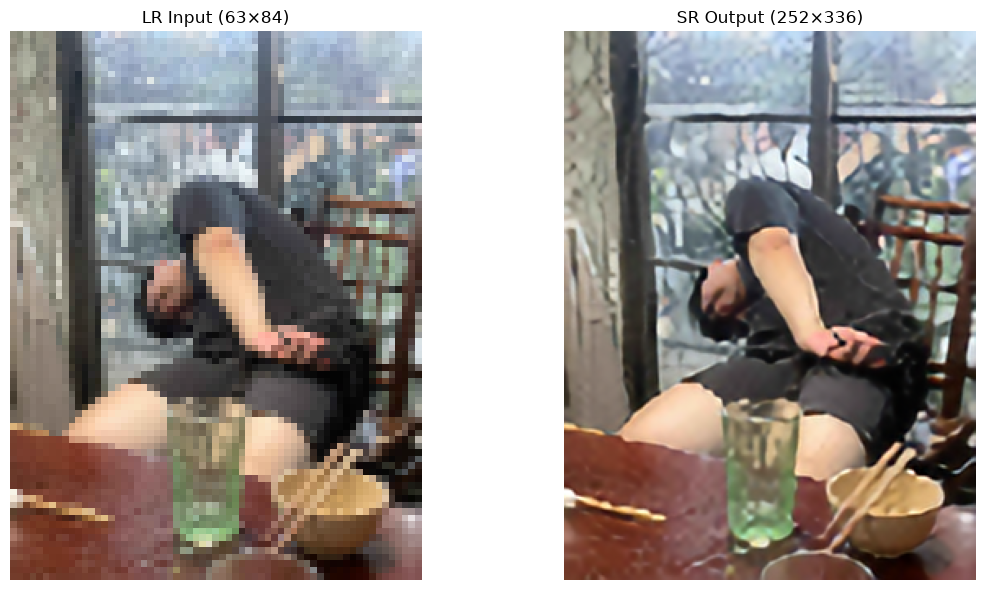

Saved: test/test_sr.png


In [5]:
model = FasterRCAN()
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

upscale_image(
    model=model,
    model_path="weights/faster_rcan_07.pth",
    image_path="test/download.png",
    output_path="test/test_sr.png",
    device=device
)